In [2]:
import pandas as pd
import numpy as np
import joblib
import os
from xgboost import XGBRegressor


In [3]:
df = pd.read_excel("../datasets/carrot_complete_growth_dataset.xlsx")

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

# Remove old avg column if exists
if "Carrot_Avg_Price" in df.columns:
    df = df.drop(columns=["Carrot_Avg_Price"])

# Create numeric average
df["Carrot_Avg_Price"] = (
    df["Carrot_Min_Price"] + df["Carrot_Max_Price"]
) / 2

df.tail()


,Date,Carrot_Min_Price,Carrot_Max_Price,Labour Cost,Transportation Cost,Fertilizer (Urea),Fertilizer(MOP),Plantation Crop,Average of tempmax_avg_75d,Average of dew_avg_75d,Average of tempmin_avg_75d,Average of temp_avg_75d,Average of windspeed_avg_75d,Average of precip_avg_75d,Average of humidity_avg_75d,Average of cloudcover_avg_75d,Average of solarradiation_avg_75d,Average of windgust_avg_75d,Average of solarenergy_avg_75d,Carrot_Avg_Price
1329,2024-12-27,200,250,1300,11320,180,300,1000,27.270263,20.301842,18.086316,22.706053,10.361579,9.743713,87.358421,74.486053,180.199737,27.152632,15.555263,225.0
1330,2024-12-28,200,250,1300,11320,180,300,1000,27.304474,20.305000,18.045263,22.713947,10.386579,9.650374,87.338947,74.250789,182.390789,27.220000,15.744737,225.0
1331,2024-12-29,250,300,1300,11320,180,300,1000,27.311842,20.300526,17.992368,22.708421,10.342632,9.569855,87.350526,73.899737,183.657105,27.131579,15.853421,275.0
1332,2024-12-30,200,240,1300,11320,180,300,1000,27.292632,20.306316,18.018421,22.687105,10.387368,9.601661,87.481842,73.817105,182.927895,27.068684,15.792895,220.0
1333,2024-12-31,180,250,1300,11320,180,300,1000,27.248158,20.312105,17.974474,22.653684,10.412632,9.666713,87.669474,74.283421,181.052632,27.100263,15.629474,215.0


In [4]:
def create_features(data):
    df_feat = data.copy()

    for lag in [1, 2, 3, 7, 14]:
        df_feat[f'avg_lag_{lag}'] = df_feat['Carrot_Avg_Price'].shift(lag)
        df_feat[f'min_lag_{lag}'] = df_feat['Carrot_Min_Price'].shift(lag)
        df_feat[f'max_lag_{lag}'] = df_feat['Carrot_Max_Price'].shift(lag)

    df_feat['day_of_week'] = df_feat['Date'].dt.dayofweek

    return df_feat


In [5]:
df_train = create_features(df)
df_train = df_train.dropna().reset_index(drop=True)

feature_cols = df_train.drop(columns=[
    'Date',
    'Carrot_Avg_Price',
    'Carrot_Min_Price',
    'Carrot_Max_Price'
]).columns

X = df_train[feature_cols]
y_min = df_train['Carrot_Min_Price']
y_max = df_train['Carrot_Max_Price']

df_train.head()


,Date,Carrot_Min_Price,Carrot_Max_Price,Labour Cost,Transportation Cost,Fertilizer (Urea),Fertilizer(MOP),Plantation Crop,Average of tempmax_avg_75d,Average of dew_avg_75d,...,avg_lag_3,min_lag_3,max_lag_3,avg_lag_7,min_lag_7,max_lag_7,avg_lag_14,min_lag_14,max_lag_14,day_of_week
0,2020-07-03,90,130,500,4160,180,300,1000,29.641886,19.942325,...,110.0,90.0,130.0,130.0,110.0,150.0,115.0,100.0,130.0,4
1,2020-07-06,90,120,500,4160,180,300,1000,29.695175,19.901096,...,110.0,100.0,120.0,135.0,120.0,150.0,110.0,100.0,120.0,0
2,2020-07-07,90,120,500,4160,180,300,1000,29.730044,19.894298,...,105.0,90.0,120.0,115.0,100.0,130.0,115.0,100.0,130.0,1
3,2020-07-08,80,120,500,4160,180,300,1000,29.728728,19.890132,...,110.0,90.0,130.0,120.0,100.0,140.0,105.0,90.0,120.0,2
4,2020-07-09,80,110,500,4160,180,300,1000,29.741447,19.899561,...,105.0,90.0,120.0,110.0,90.0,130.0,85.0,70.0,100.0,3


In [6]:
model_min = XGBRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model_max = XGBRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model_min.fit(X, y_min)
model_max.fit(X, y_max)

print("Models trained successfully.")


Models trained successfully.


In [7]:
def forecast_next_30_days(model_min, model_max, base_df, days=30):

    df_base = base_df.copy().reset_index(drop=True)
    predictions = []

    for i in range(days):

        df_feat = create_features(df_base)
        df_feat = df_feat.dropna()

        last_row_feat = df_feat.iloc[-1]
        X_input = last_row_feat[feature_cols].values.reshape(1, -1)

        pred_min_raw = model_min.predict(X_input)[0]
        pred_max_raw = model_max.predict(X_input)[0]

        prev_min = df_base.iloc[-1]['Carrot_Min_Price']
        prev_max = df_base.iloc[-1]['Carrot_Max_Price']

        # Trend continuation
        if len(df_base) > 1:
            trend_min = prev_min - df_base.iloc[-2]['Carrot_Min_Price']
            trend_max = prev_max - df_base.iloc[-2]['Carrot_Max_Price']
        else:
            trend_min = 0
            trend_max = 0

        pred_min = pred_min_raw + 0.2 * trend_min
        pred_max = pred_max_raw + 0.2 * trend_max

        # Small natural variation (very small noise)
        noise_min = np.random.normal(0, prev_min * 0.003)
        noise_max = np.random.normal(0, prev_max * 0.003)

        pred_min += noise_min
        pred_max += noise_max

        # Stability control ±6%
        pred_min = np.clip(pred_min, prev_min * 0.94, prev_min * 1.06)
        pred_max = np.clip(pred_max, prev_max * 0.94, prev_max * 1.06)

        if pred_min > pred_max:
            pred_max = pred_min * 1.05

        next_date = df_base.iloc[-1]['Date'] + pd.Timedelta(days=1)

        new_row = {
            "Date": next_date,
            "Carrot_Min_Price": pred_min,
            "Carrot_Max_Price": pred_max,
            "Carrot_Avg_Price": (pred_min + pred_max) / 2
        }

        df_base = pd.concat([df_base, pd.DataFrame([new_row])], ignore_index=True)

        predictions.append({
            "Date": next_date,
            "Predicted_Min": round(pred_min, 2),
            "Predicted_Max": round(pred_max, 2),
            "Predicted_Avg": round((pred_min + pred_max) / 2, 2)
        })

    return pd.DataFrame(predictions)


In [8]:
forecast_df = forecast_next_30_days(model_min, model_max, df, days=30)

forecast_df.head()


,Date,Predicted_Min,Predicted_Max,Predicted_Avg
0,2025-01-01,178.12,246.08,212.10
1,2025-01-02,181.82,243.54,212.68
2,2025-01-03,183.15,243.08,213.12
3,2025-01-04,181.25,243.82,212.54
4,2025-01-05,182.57,244.34,213.45


In [10]:
forecast_df



,Date,Predicted_Min,Predicted_Max,Predicted_Avg
0,2025-01-01,178.12,246.08,212.10
1,2025-01-02,181.82,243.54,212.68
2,2025-01-03,183.15,243.08,213.12
3,2025-01-04,181.25,243.82,212.54
4,2025-01-05,182.57,244.34,213.45
5,2025-01-06,183.53,244.40,213.96
6,2025-01-07,182.22,244.26,213.24
7,2025-01-08,181.30,244.95,213.13
8,2025-01-09,183.50,243.97,213.74
9,2025-01-10,182.80,243.34,213.07


RMSE Min: 31.12
RMSE Max: 32.35

Forecast Preview:
        Date Predicted_Min_Range Predicted_Max_Range  Predicted_Avg
0 2025-02-01       135.5 - 188.4       189.4 - 254.1         194.18
1 2025-02-02       150.8 - 204.4       205.4 - 270.1         209.84
2 2025-02-03       154.3 - 199.8       200.8 - 265.5         209.27
3 2025-02-04       155.0 - 198.7       199.7 - 264.4         209.10
4 2025-02-05       157.9 - 199.6       200.6 - 265.3         211.00
5 2025-02-06       161.8 - 203.1       204.1 - 268.8         214.68
6 2025-02-07       165.4 - 206.5       207.5 - 272.2         218.19
7 2025-02-08       169.1 - 210.6       211.6 - 276.3         222.05
8 2025-02-09       172.8 - 214.9       215.9 - 280.6         226.05
9 2025-02-10       176.4 - 219.4       220.4 - 285.1         230.16

Forecast saved as:
✔ carrot_price_forecast.csv
✔ carrot_price_forecast.xlsx


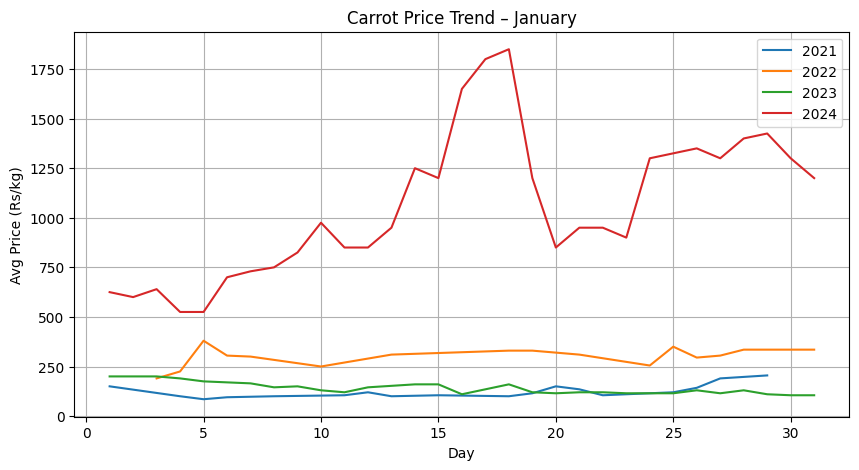

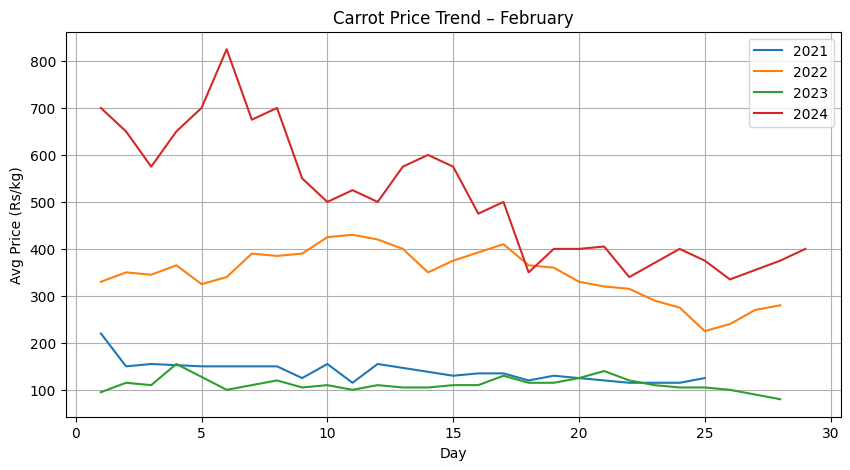

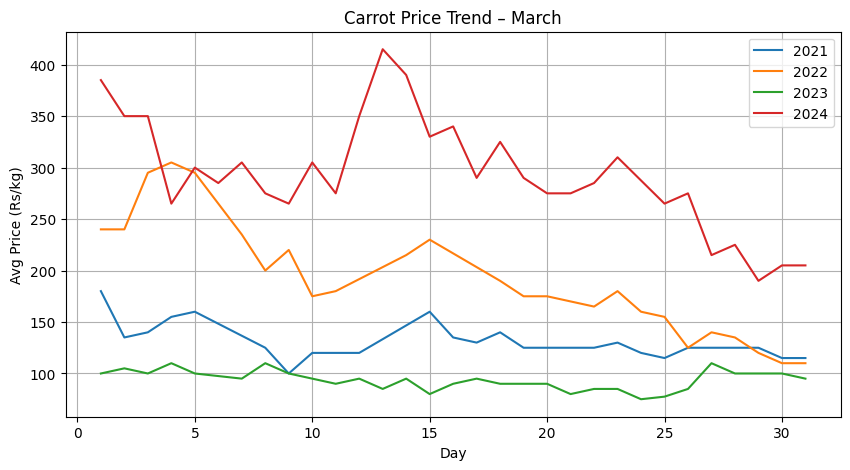

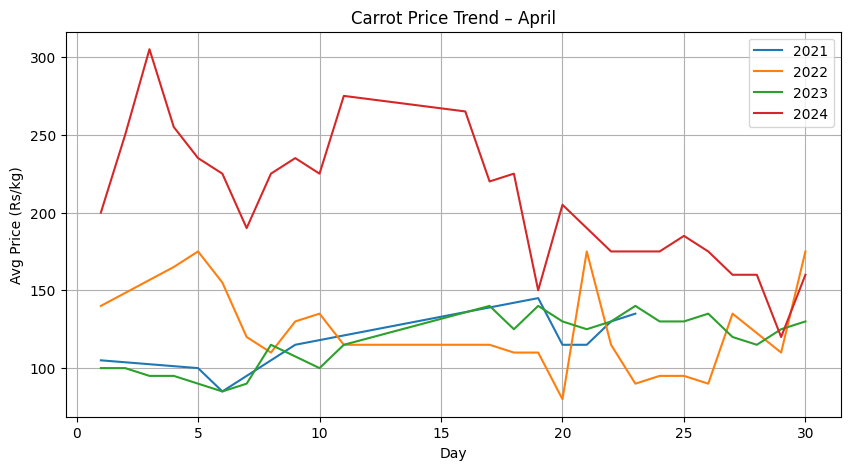

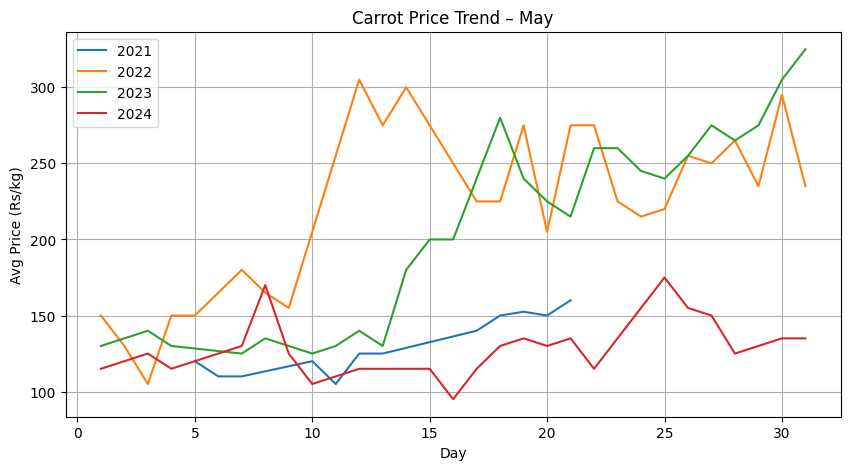

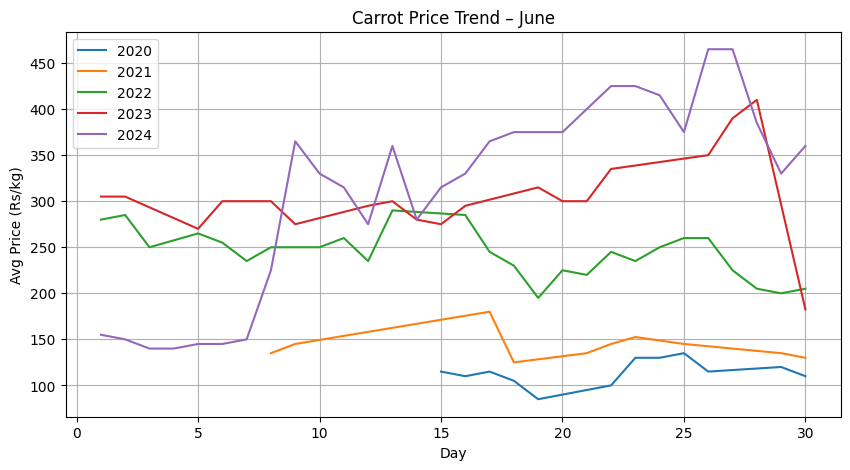

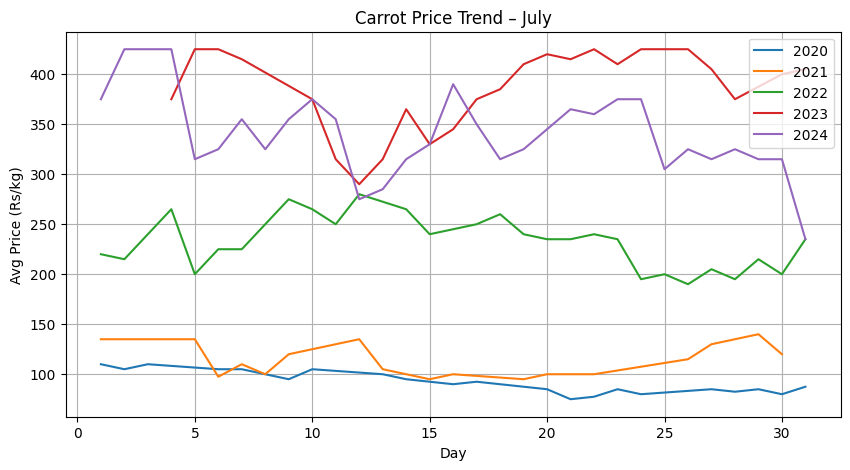

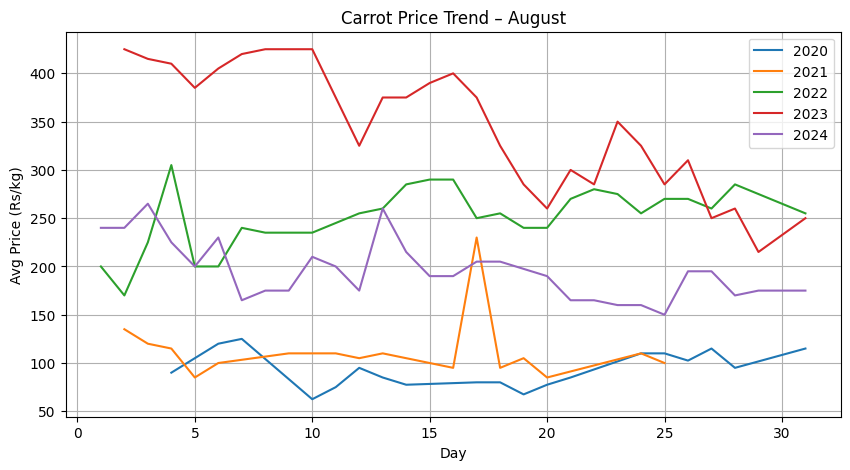

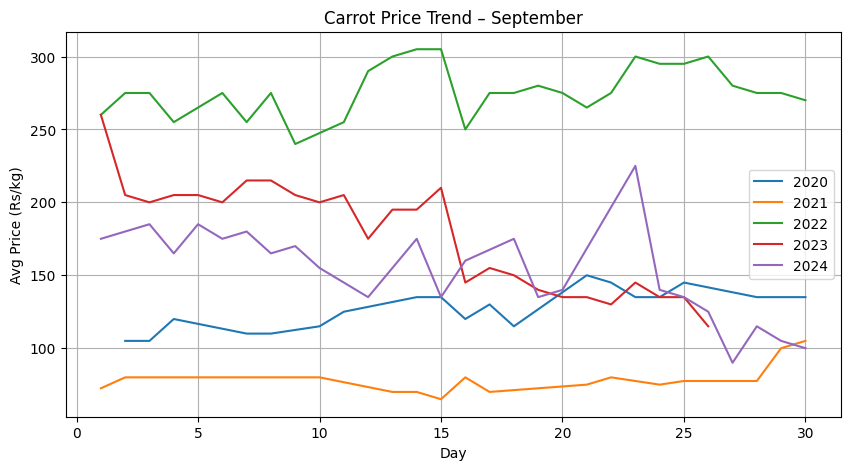

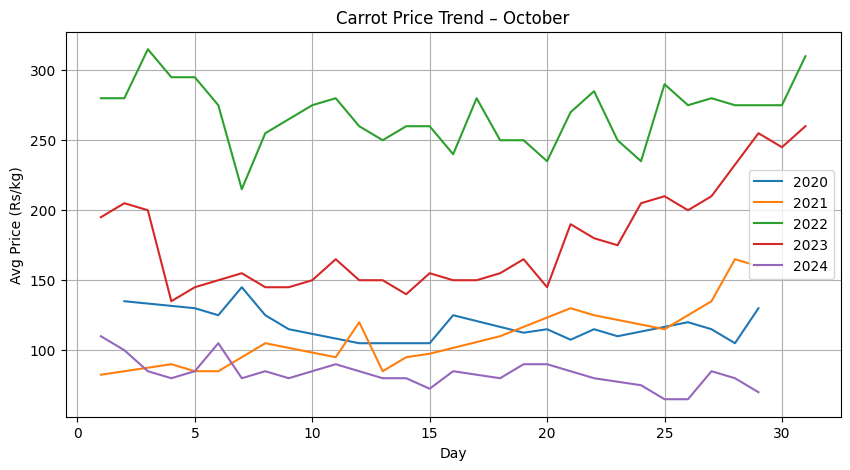

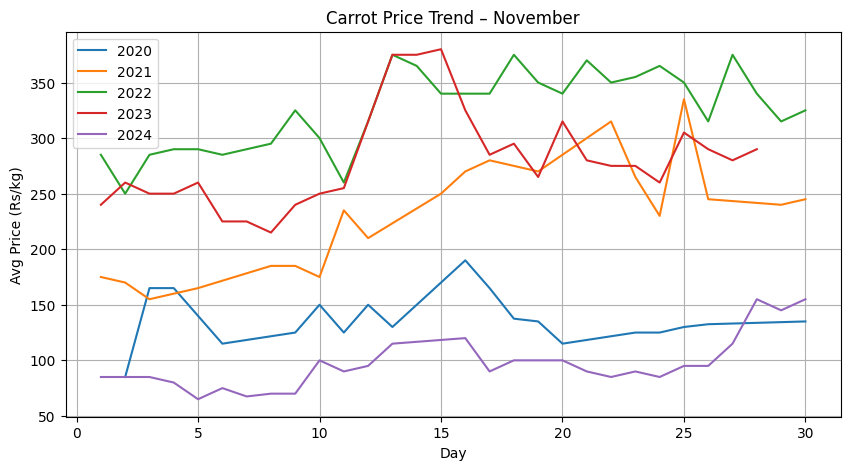

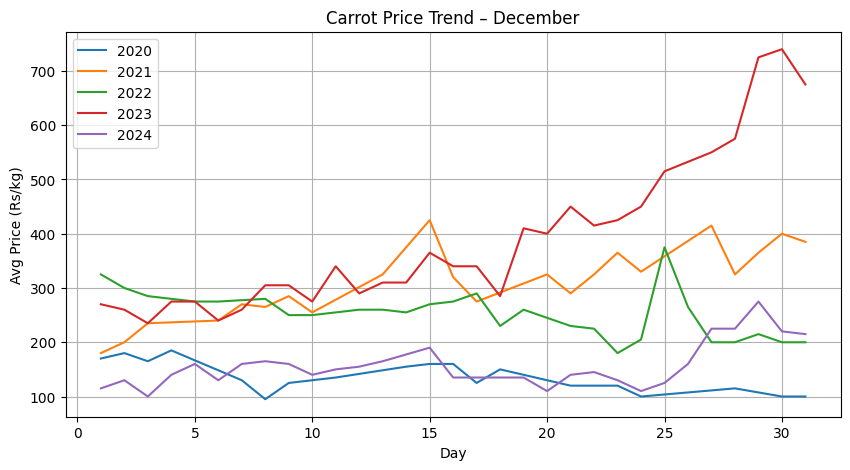

In [12]:
 # =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression


# =========================
# 2. LOAD DATA
# =========================
file_path = "../datasets/carrot_complete_growth_dataset.xlsx"
df = pd.read_excel(file_path)

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)


# =========================
# 3. CREATE LAG FEATURES
# =========================
df["min_lag_1"] = df["Carrot_Min_Price"].shift(1)
df["min_lag_3"] = df["Carrot_Min_Price"].shift(3)
df["min_lag_7"] = df["Carrot_Min_Price"].shift(7)

df["max_lag_1"] = df["Carrot_Max_Price"].shift(1)
df["max_lag_3"] = df["Carrot_Max_Price"].shift(3)
df["max_lag_7"] = df["Carrot_Max_Price"].shift(7)

feature_cols = [
    "Labour Cost",
    "Transportation Cost",
    "Fertilizer (Urea)",
    "Fertilizer(MOP)",
    "min_lag_1", "min_lag_3", "min_lag_7",
    "max_lag_1", "max_lag_3", "max_lag_7"
]

X = df[feature_cols]
y_min = df["Carrot_Min_Price"]
y_max = df["Carrot_Max_Price"]

data = pd.concat([X, y_min, y_max], axis=1)
data = data.dropna().reset_index(drop=True)

X = data[feature_cols]
y_min = data["Carrot_Min_Price"]
y_max = data["Carrot_Max_Price"]


# =========================
# 4. TRAIN–TEST SPLIT (TIME-BASED)
# =========================
split_index = int(len(data) * 0.8)

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_min_train, y_min_test = y_min.iloc[:split_index], y_min.iloc[split_index:]
y_max_train, y_max_test = y_max.iloc[:split_index], y_max.iloc[split_index:]


# =========================
# 5. TRAIN MODELS
# =========================
lr_min = LinearRegression()
lr_max = LinearRegression()

lr_min.fit(X_train, y_min_train)
lr_max.fit(X_train, y_max_train)

y_min_pred = lr_min.predict(X_test)
y_max_pred = lr_max.predict(X_test)

rmse_min = np.sqrt(mean_squared_error(y_min_test, y_min_pred))
rmse_max = np.sqrt(mean_squared_error(y_max_test, y_max_pred))

print("RMSE Min:", round(rmse_min, 2))
print("RMSE Max:", round(rmse_max, 2))


# =========================
# 6. FUTURE FORECASTING
# =========================
forecast_dates = pd.date_range("2025-02-01", "2025-03-31", freq="D")

last_row = df.iloc[-1]

min_lag_1 = last_row["Carrot_Min_Price"]
min_lag_3 = df.iloc[-3]["Carrot_Min_Price"]
min_lag_7 = df.iloc[-7]["Carrot_Min_Price"]

max_lag_1 = last_row["Carrot_Max_Price"]
max_lag_3 = df.iloc[-3]["Carrot_Max_Price"]
max_lag_7 = df.iloc[-7]["Carrot_Max_Price"]

predictions = []

for date in forecast_dates:

    X_pred = pd.DataFrame([{
        "Labour Cost": last_row["Labour Cost"],
        "Transportation Cost": last_row["Transportation Cost"],
        "Fertilizer (Urea)": last_row["Fertilizer (Urea)"],
        "Fertilizer(MOP)": last_row["Fertilizer(MOP)"],
        "min_lag_1": min_lag_1,
        "min_lag_3": min_lag_3,
        "min_lag_7": min_lag_7,
        "max_lag_1": max_lag_1,
        "max_lag_3": max_lag_3,
        "max_lag_7": max_lag_7
    }])

    pred_min = lr_min.predict(X_pred)[0]
    pred_max = lr_max.predict(X_pred)[0]

    # =========================
    # 7. INTERVAL FORECASTING
    # =========================
    min_low  = pred_min - rmse_min
    min_high = pred_min + rmse_min

    max_low  = pred_max - rmse_max
    max_high = pred_max + rmse_max

    if min_high >= max_low:
        min_high = max_low - 1

    predictions.append({
        "Date": date,
        "Predicted_Min_Range": f"{round(min_low,1)} - {round(min_high,1)}",
        "Predicted_Max_Range": f"{round(max_low,1)} - {round(max_high,1)}",
        "Predicted_Avg": round((pred_min + pred_max) / 2, 2)
    })

    # Recursive update
    min_lag_7 = min_lag_3
    min_lag_3 = min_lag_1
    min_lag_1 = pred_min

    max_lag_7 = max_lag_3
    max_lag_3 = max_lag_1
    max_lag_1 = pred_max


forecast_df = pd.DataFrame(predictions)

print("\nForecast Preview:")
print(forecast_df.head(10))


# =========================
# 8. SAVE FORECAST (IMPORTANT)
# =========================
forecast_df.to_csv("carrot_price_forecast.csv", index=False)
forecast_df.to_excel("carrot_price_forecast.xlsx", index=False)

print("\nForecast saved as:")
print("✔ carrot_price_forecast.csv")
print("✔ carrot_price_forecast.xlsx")


# =========================
# 9. SEASONAL VISUALIZATION
# =========================
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day

df["Avg_Price"] = (df["Carrot_Min_Price"] + df["Carrot_Max_Price"]) / 2

month_names = {
    1: "January", 2: "February", 3: "March", 4: "April",
    5: "May", 6: "June", 7: "July", 8: "August",
    9: "September", 10: "October", 11: "November", 12: "December"
}

for month in range(1, 13):
    plt.figure(figsize=(10,5))
    mdf = df[df["Month"] == month]

    for y in sorted(mdf["Year"].unique()):
        plt.plot(
            mdf[mdf["Year"] == y]["Day"],
            mdf[mdf["Year"] == y]["Avg_Price"],
            label=str(y)
        )

    plt.title(f"Carrot Price Trend – {month_names[month]}")
    plt.xlabel("Day")
    plt.ylabel("Avg Price (Rs/kg)")
    plt.legend()
    plt.grid(True)
    plt.show()
